# Zillow Assessed Property Value Prediction

## Project Goal

The goal of this project is to predict 2016 tax-assessed property values using the Zillow property dataset. I compare several regression models, tune the strongest ones, and evaluate the final model on a separate test set.

### Workflow
**Data Review → Cleaning → Feature Engineering → Model Comparison → Tuning → Final Evaluation → Error Analysis → Feature Importance**


## 1. Executive Summary

I built and compared several regression models to predict Zillow tax-assessed property values. After tuning the strongest model families, Gradient Boosting had the best cross-validation result and was selected as the final model.

The final model achieved a **test RMSE of $438,823**, a **test MAE of $195,897**, and an **R² of 0.557**. The cross-validation RMSE was **$429,443**, which was fairly close to the test RMSE. This suggests the model's test performance was consistent with what I saw during model development. Location, finished square footage, building quality, and property type were among the most useful predictors. The biggest errors came from very high-value properties.


## 2. Introduction

Property values depend on many factors such as location, size, age, condition, and property type. In this project, I use Zillow property data to see how well these available features can predict tax-assessed value.

I use **RMSE** as the main metric because it gives more weight to large prediction errors. I also report **MAE** and **R²** for the final model.


## 3. Modeling Approach

I split the data into training and test sets before fitting any preprocessing steps.

- **5-fold cross-validation** is used for the baseline model comparison.
- **3-fold cross-validation** is used for parameter tuning to keep runtime manageable.
- The **20% test set** is only used after the final model is selected.
- Imputation, encoding, and scaling are included inside the modeling pipeline so the same process is applied consistently during cross-validation.


In [1]:
# Imports and reproducibility settings
import os
import time
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.parse import urlparse

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    RandomizedSearchCV,
    GridSearchCV,
    validation_curve,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    BaggingRegressor,
    AdaBoostRegressor,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42
DATASET_YEAR = 2016
TARGET = "taxvaluedollarcnt"
TEST_SIZE = 0.20
MISSING_COLUMN_THRESHOLD = 0.80

# Runtime controls for the standard run.
RUN_MODE = "standard"
GB_SEARCH_ITER = 20
RF_SEARCH_ITER = 15
PERMUTATION_REPEATS = 5

print("Run mode:", RUN_MODE)
print("Gradient Boosting random-search iterations:", GB_SEARCH_ITER)
print("Random Forest random-search iterations:", RF_SEARCH_ITER)


Run mode: standard
Gradient Boosting random-search iterations: 20
Random Forest random-search iterations: 15


In [2]:
# Helper functions

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def dollar(x):
    return f"${x:,.0f}"


def make_ohe():
    """Compatibility helper for older/newer scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def add_engineered_features(data, dataset_year=DATASET_YEAR):
    """Deterministic feature engineering. No parameters are learned from the data."""
    data = data.copy()

    # In this Zillow extract, missing poolcnt is used as no recorded pool.
    if "poolcnt" in data.columns:
        data["poolcnt"] = data["poolcnt"].fillna(0)

    if "yearbuilt" in data.columns:
        age = dataset_year - data["yearbuilt"]
        age = age.where(age >= 0, np.nan)
        data["property_age"] = age
        data["log_property_age"] = np.log1p(age)

    if {"bedroomcnt", "bathroomcnt"}.issubset(data.columns):
        data["bed_to_bath_ratio"] = data["bedroomcnt"] / (data["bathroomcnt"] + 1)
        data["bed_bath_product"] = data["bedroomcnt"] * data["bathroomcnt"]

    for col in ["bedroomcnt", "bathroomcnt", "numberofstories"]:
        if col in data.columns:
            data[f"{col}_sq"] = data[col] ** 2

    for col in ["calculatedfinishedsquarefeet", "lotsizesquarefeet", "garagetotalsqft"]:
        if col in data.columns:
            clipped = data[col].clip(lower=0)
            data[f"log_{col}"] = np.log1p(clipped)

    return data


def make_preprocessor(X):
    """Create a fresh preprocessing transformer for a supplied training feature frame."""
    categorical_candidates = [
        "fips",
        "propertylandusetypeid",
        "airconditioningtypeid",
        "heatingorsystemtypeid",
    ]
    categorical_cols = [c for c in categorical_candidates if c in X.columns]
    numeric_cols = [c for c in X.columns if c not in categorical_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
        ("onehot", make_ohe()),
    ])

    transformers = [("num", numeric_pipe, numeric_cols)]
    if categorical_cols:
        transformers.append(("cat", categorical_pipe, categorical_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return preprocessor, numeric_cols, categorical_cols


def make_model_pipeline(X, model):
    preprocessor, _, _ = make_preprocessor(X)
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", model),
    ])


def evaluate_cv(name, model, X_train, y_train, cv):
    pipe = make_model_pipeline(X_train, model)
    start = time.time()
    scores = -cross_val_score(
        pipe,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
    )
    return {
        "Model": name,
        "Mean CV RMSE": scores.mean(),
        "CV RMSE Std": scores.std(),
        "Runtime (sec)": time.time() - start,
    }


def sweep_parameter(model, model_param, values, X_train, y_train, cv):
    """Leakage-safe one-parameter sweep. Preprocessing remains inside every CV fold."""
    rows = []
    for value in values:
        estimator = clone(model)
        estimator.set_params(**{model_param: value})
        pipe = make_model_pipeline(X_train, estimator)
        scores = -cross_val_score(
            pipe,
            X_train,
            y_train,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
        )
        rows.append({
            "Parameter": model_param,
            "Value": value,
            "Mean CV RMSE": scores.mean(),
            "CV RMSE Std": scores.std(),
        })
    return pd.DataFrame(rows)


## 4. Data Description

The dataset contains Zillow property records from 2016. It includes property size, bedrooms and bathrooms, location information, building characteristics, land-use fields, and other property details.

The target variable is **`taxvaluedollarcnt`**, which represents the tax-assessed property value.


In [3]:
# Load the Zillow dataset
DATA_URL = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"
DATA_FILE = os.path.basename(urlparse(DATA_URL).path)

if not os.path.exists(DATA_FILE):
    print("Downloading dataset...")
    response = requests.get(DATA_URL, timeout=120)
    response.raise_for_status()
    with open(DATA_FILE, "wb") as f:
        f.write(response.content)

raw_df = pd.read_csv(DATA_FILE)

print("Raw dataset shape:", raw_df.shape)
display(raw_df.head())


Raw dataset shape: (77613, 55)


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,3100.0,3100.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,633.0,NaN,NaN,33634931.0,-117869207.0,4506.0,NaN,NaN,NaN,NaN,NaN,122,261.0,NaN,6.059063e+07,53571.0,1286.0,NaN,96978.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,1465.0,1465.0,NaN,NaN,1465.0,NaN,6111.0,1.0,1.0,1.0,0.0,NaN,NaN,34449266.0,-119281531.0,12647.0,NaN,NaN,NaN,NaN,NaN,1110,261.0,NaN,6.111001e+07,13091.0,2061.0,NaN,97099.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,1243.0,1243.0,NaN,NaN,NaN,NaN,6059.0,NaN,2.0,2.0,440.0,NaN,NaN,33886168.0,-117823170.0,8432.0,1.0,NaN,NaN,NaN,1.0,122,261.0,NaN,6.059022e+07,21412.0,1286.0,NaN,97078.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,2376.0,2376.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34245180.0,-118240722.0,13038.0,1.0,NaN,NaN,NaN,1.0,0101,261.0,LCR110000*,6.037300e+07,396551.0,3101.0,NaN,96330.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,1312.0,1312.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34185120.0,-118414640.0,278581.0,1.0,NaN,NaN,NaN,1.0,010C,266.0,LAR3,6.037124e+07,12447.0,3101.0,268548.0,96451.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
# Dataset structure and descriptive statistics
raw_df.info()
display(raw_df.describe(include="all").T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
parcelid,77613.0,NaN,NaN,NaN,13007807.003633,3518717.006869,10711855.0,11538209.0,12530044.0,14211010.0,167689317.0
airconditioningtypeid,25007.0,NaN,NaN,NaN,1.812013,2.965768,1.0,1.0,1.0,1.0,13.0
architecturalstyletypeid,207.0,NaN,NaN,NaN,7.386473,2.72803,2.0,7.0,7.0,7.0,21.0
basementsqft,50.0,NaN,NaN,NaN,679.72,689.703546,38.0,273.0,515.0,796.5,3560.0
bathroomcnt,77579.0,NaN,NaN,NaN,2.298496,0.996732,0.0,2.0,2.0,3.0,18.0
bedroomcnt,77579.0,NaN,NaN,NaN,3.053223,1.14048,0.0,2.0,3.0,4.0,16.0
buildingclasstypeid,15.0,NaN,NaN,NaN,3.933333,0.258199,3.0,4.0,4.0,4.0,4.0
buildingqualitytypeid,49809.0,NaN,NaN,NaN,6.533779,1.722062,1.0,6.0,6.0,8.0,12.0
calculatedbathnbr,76963.0,NaN,NaN,NaN,2.316392,0.979689,1.0,2.0,2.0,3.0,18.0
decktypeid,614.0,NaN,NaN,NaN,66.0,0.0,66.0,66.0,66.0,66.0,66.0


,Missing Count,Missing %,Unique Values
buildingclasstypeid,77598,99.98,2
finishedsquarefeet13,77571,99.95,13
basementsqft,77563,99.94,43
storytypeid,77563,99.94,1
yardbuildingsqft26,77543,99.91,59
fireplaceflag,77441,99.78,1
architecturalstyletypeid,77406,99.73,5
typeconstructiontypeid,77390,99.71,4
finishedsquarefeet6,77227,99.50,350
pooltypeid10,77148,99.40,1


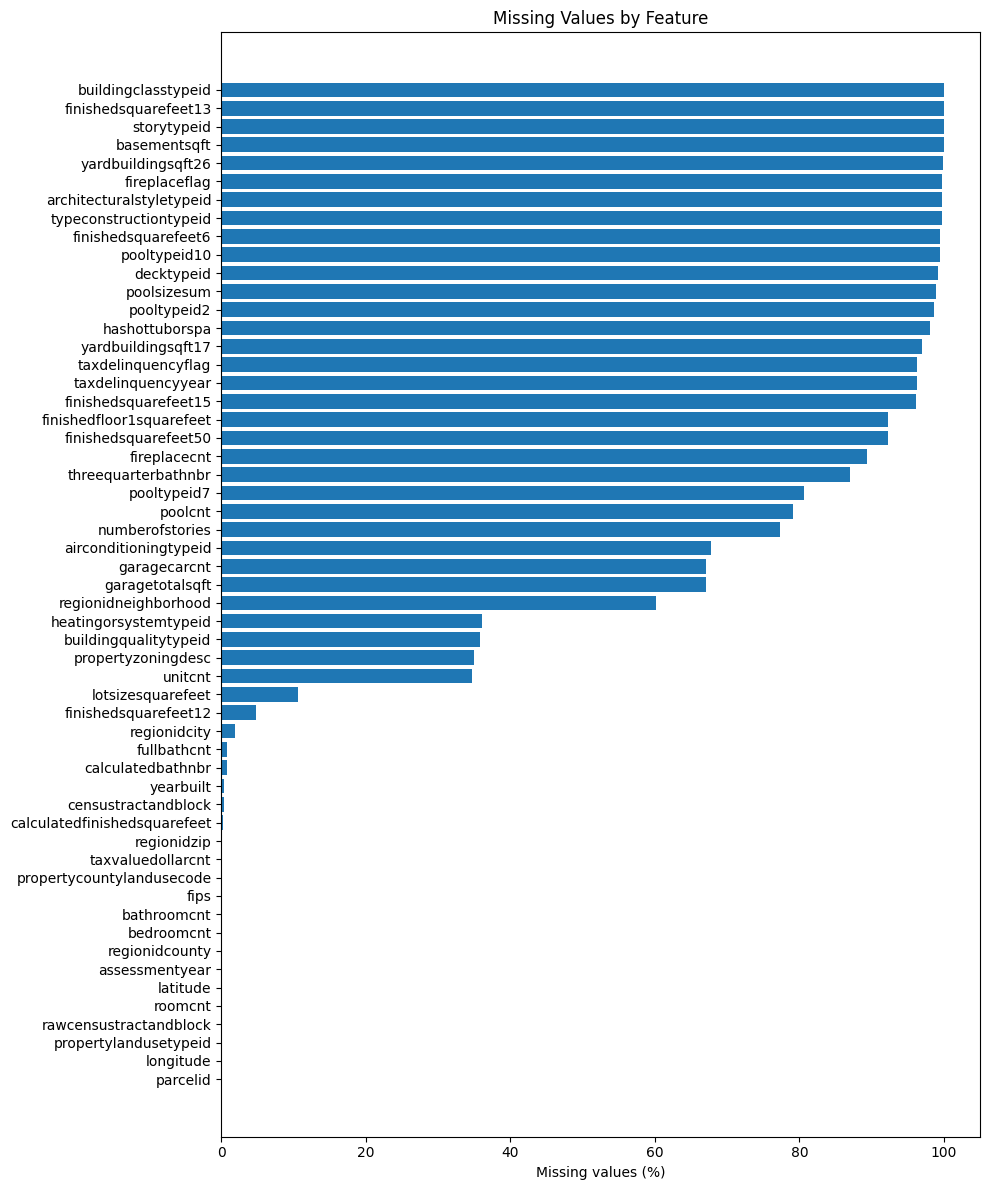

In [5]:
# Missing-value summary
missing_summary = pd.DataFrame({
    "Missing Count": raw_df.isna().sum(),
    "Missing %": (raw_df.isna().mean() * 100).round(2),
    "Unique Values": raw_df.nunique(dropna=True),
}).sort_values("Missing %", ascending=False)

display(missing_summary)

plot_missing = missing_summary.sort_values("Missing %")
plt.figure(figsize=(10, 12))
plt.barh(plot_missing.index, plot_missing["Missing %"])
plt.xlabel("Missing values (%)")
plt.title("Missing Values by Feature")
plt.tight_layout()
plt.show()


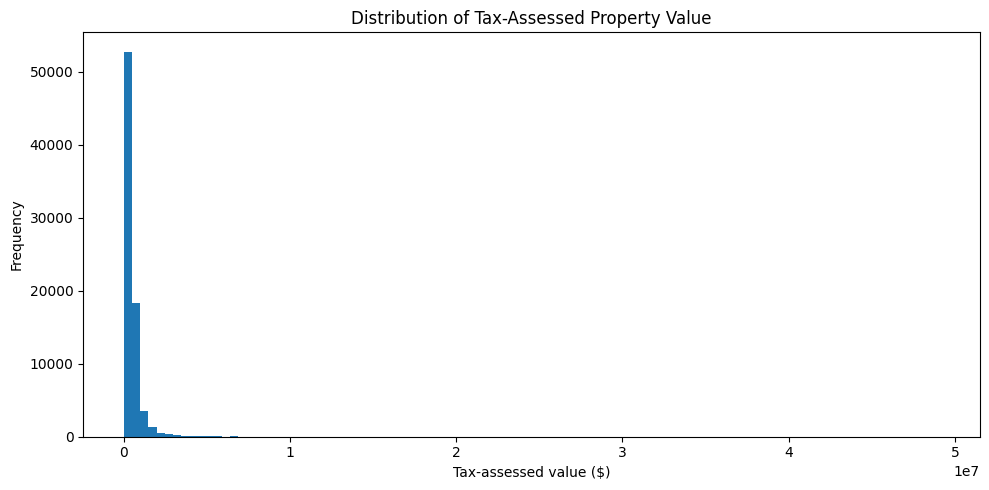

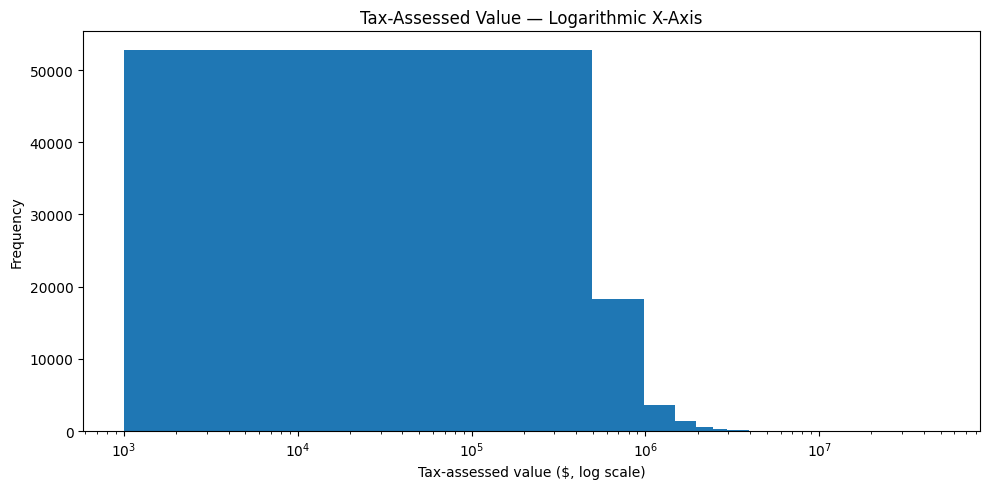

Target observations: 77,578
Mean:   $490,151
Median: $358,878
Min:    $1,000
Max:    $49,061,236


In [6]:
# Target distribution on the original dollar scale and log-x scale
values = raw_df[TARGET].dropna()

plt.figure(figsize=(10, 5))
plt.hist(values, bins=100)
plt.xlabel("Tax-assessed value ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Tax-Assessed Property Value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(values, bins=100)
plt.xscale("log")
plt.xlabel("Tax-assessed value ($, log scale)")
plt.ylabel("Frequency")
plt.title("Tax-Assessed Value — Logarithmic X-Axis")
plt.tight_layout()
plt.show()

print("Target observations:", f"{len(values):,}")
print("Mean:  ", dollar(values.mean()))
print("Median:", dollar(values.median()))
print("Min:   ", dollar(values.min()))
print("Max:   ", dollar(values.max()))


### Data Review

The original dataset contains **77,613 rows and 55 columns**. The target is available for **77,578 properties**.

The target values are strongly right-skewed. The median assessed value is about **$358,878**, while the mean is higher at about **$490,151**. The maximum value is over **$49 million**, showing that a small number of very expensive properties create a long upper tail.

Missing data is also a major issue. Several variables are missing for more than 80% of the properties, so those very sparse columns are removed later in the cleaning process.


## 5. Data Cleaning and Preprocessing

I used the following cleaning steps:

- Removed duplicate parcel records.
- Removed rows with a missing target value.
- Removed identifier, redundant, and very high-cardinality fields that were not useful for modeling.
- Kept latitude and longitude because they provide detailed location information.
- Used `fips` for county information and removed redundant county fields.
- Removed columns with more than 80% missing values based on the training data.
- Kept rows even when some predictor values were missing and handled those missing values later through imputation.
- Kept high-value properties in the main dataset instead of removing them as target outliers.


In [7]:
# Initial cleaning that is safe to perform before train/test splitting
model_df = raw_df.copy()

# 1) Remove duplicate parcel observations before dropping parcelid.
if "parcelid" in model_df.columns:
    rows_before = len(model_df)
    model_df = model_df.drop_duplicates(subset="parcelid", keep="first").copy()
    duplicate_rows_removed = rows_before - len(model_df)
else:
    duplicate_rows_removed = 0

# 2) Target must be observed.
rows_before_target = len(model_df)
model_df = model_df.dropna(subset=[TARGET]).copy()
missing_target_rows_removed = rows_before_target - len(model_df)

# 3) Predetermined columns excluded for identification, redundancy, or very high-cardinality text.
# Latitude/longitude are intentionally retained for fine-grained location information.
manual_drop = [
    "parcelid",
    "propertycountylandusecode",
    "propertyzoningdesc",
    "rawcensustractandblock",
    "censustractandblock",
    "calculatedbathnbr",
    "fullbathcnt",
    "assessmentyear",
    "regionidcounty",
    "regionidzip",
    "regionidcity",
    "regionidneighborhood",
    "finishedsquarefeet12",
]

model_df = model_df.drop(columns=[c for c in manual_drop if c in model_df.columns]).copy()

print("Duplicate parcel rows removed:", f"{duplicate_rows_removed:,}")
print("Rows removed for missing target:", f"{missing_target_rows_removed:,}")
print("Rows available before train/test split:", f"{len(model_df):,}")
print("Columns after predetermined drops:", model_df.shape[1])


Duplicate parcel rows removed: 199
Rows removed for missing target: 34
Rows available before train/test split: 77,380
Columns after predetermined drops: 42


In [8]:
# Split BEFORE learning missingness thresholds, imputers, encoders, scalers, or model parameters.
X = model_df.drop(columns=[TARGET]).copy()
y = model_df[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

# Sparse-column decision is based on training predictors only.
train_missing_rates = X_train_raw.isna().mean()
sparse_columns = train_missing_rates[train_missing_rates > MISSING_COLUMN_THRESHOLD].index.tolist()

X_train_raw = X_train_raw.drop(columns=sparse_columns).copy()
X_test_raw = X_test_raw.drop(columns=sparse_columns, errors="ignore").copy()

# Deterministic feature engineering can be performed before CV because it learns no statistics.
X_train = add_engineered_features(X_train_raw)
X_test = add_engineered_features(X_test_raw)

# Keep train/test columns perfectly aligned.
X_test = X_test.reindex(columns=X_train.columns)

retained_rows = len(model_df)
raw_target_rows = raw_df[TARGET].notna().sum()
retention_pct = 100 * retained_rows / raw_target_rows

print("Training rows:", f"{len(X_train):,}")
print("Test rows:    ", f"{len(X_test):,}")
print("Total retained rows:", f"{retained_rows:,}")
print(f"Retention vs. rows with observed target: {retention_pct:.2f}%")
print("Columns dropped for >80% training missingness:")
print(sparse_columns)
print("Final raw/engineered predictor count:", X_train.shape[1])


Training rows: 61,904
Test rows:     15,476
Total retained rows: 77,380
Retention vs. rows with observed target: 99.74%
Columns dropped for >80% training missingness:
['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'hashottuborspa', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']
Final raw/engineered predictor count: 28


,Stage,Rows,% of raw
0,Raw rows,77613,100.000000
1,Rows with observed target,77578,99.954904
2,After duplicate removal + observed target,77380,99.699793
3,Final modeling rows,77380,99.699793


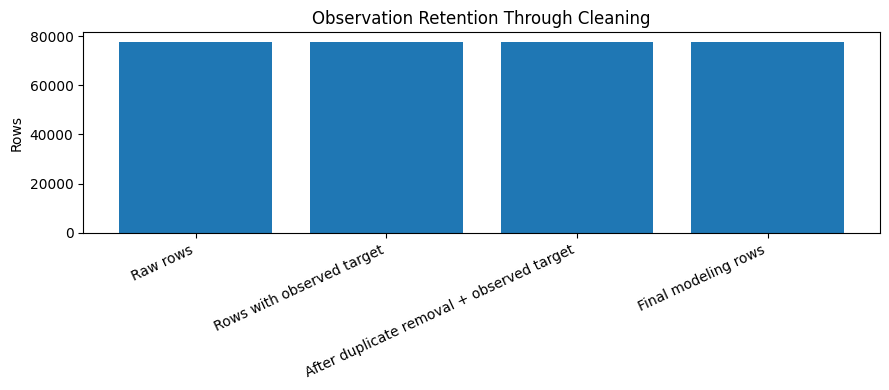

In [9]:
# Data-retention audit
retention_audit = pd.DataFrame({
    "Stage": [
        "Raw rows",
        "Rows with observed target",
        "After duplicate removal + observed target",
        "Final modeling rows",
    ],
    "Rows": [
        len(raw_df),
        int(raw_df[TARGET].notna().sum()),
        len(model_df),
        len(X_train) + len(X_test),
    ],
})
retention_audit["% of raw"] = 100 * retention_audit["Rows"] / len(raw_df)
display(retention_audit)

plt.figure(figsize=(9, 4))
plt.bar(retention_audit["Stage"], retention_audit["Rows"])
plt.ylabel("Rows")
plt.title("Observation Retention Through Cleaning")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Cleaning Results

I removed **199 duplicate parcel records** and **34 rows with a missing target**. This left **77,380 properties** for modeling, which is about **99.7% of the original dataset**.

After the train/test split, columns with more than 80% missing values in the training set were removed. The final dataset had **28 predictors** after cleaning and feature engineering.

Keeping rows with missing predictors allowed me to use much more of the available data instead of dropping a large part of the dataset.


## 6. Feature Engineering

I created several additional features to capture relationships that may not be represented well by the original variables:

- Property age using `2016 - yearbuilt`
- Log of property age
- Bedroom-to-bathroom ratio
- Bedroom × bathroom interaction
- Squared bedroom, bathroom, and story counts
- Log transformations of finished square footage, lot size, and garage size

These features were added before modeling and were created the same way for both training and test data.


In [10]:
# Inspect final training features before learned preprocessing
print("Engineered training feature count:", X_train.shape[1])
display(X_train.head())

engineered_cols = [c for c in X_train.columns if c not in X_train_raw.columns]
print("Engineered features:")
for c in engineered_cols:
    print("•", c)


Engineered training feature count: 28


,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,fips,garagecarcnt,garagetotalsqft,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,propertylandusetypeid,roomcnt,unitcnt,yearbuilt,numberofstories,property_age,log_property_age,bed_to_bath_ratio,bed_bath_product,bedroomcnt_sq,bathroomcnt_sq,numberofstories_sq,log_calculatedfinishedsquarefeet,log_lotsizesquarefeet,log_garagetotalsqft
52900,1.0,2.0,2.0,8.0,1226.0,6037.0,NaN,NaN,2.0,34104300.0,-118314000.0,19574.0,0.0,266.0,0.0,1.0,1962.0,NaN,54.0,4.007333,0.666667,4.0,4.0,4.0,NaN,7.112327,9.882009,NaN
6457,1.0,3.0,3.0,8.0,1744.0,6037.0,NaN,NaN,2.0,34605194.0,-118183571.0,6672.0,0.0,261.0,0.0,1.0,1992.0,NaN,24.0,3.218876,0.750000,9.0,9.0,9.0,NaN,7.464510,8.805825,NaN
38056,1.0,2.0,2.0,8.0,1125.0,6037.0,NaN,NaN,2.0,34187900.0,-118391000.0,12824.0,1.0,266.0,0.0,1.0,1978.0,NaN,38.0,3.663562,0.666667,4.0,4.0,4.0,NaN,7.026427,9.459152,NaN
15060,NaN,3.0,3.0,NaN,1682.0,6059.0,1.0,390.0,NaN,33739438.0,-118101340.0,2938.0,0.0,261.0,0.0,NaN,1999.0,NaN,17.0,2.890372,0.750000,9.0,9.0,9.0,NaN,7.428333,7.985825,5.968708
7247,NaN,1.0,2.0,4.0,948.0,6037.0,NaN,NaN,7.0,34105591.0,-117965291.0,6378.0,0.0,261.0,0.0,1.0,1953.0,NaN,63.0,4.158883,1.000000,2.0,4.0,1.0,NaN,6.855409,8.760767,NaN


Engineered features:
• property_age
• log_property_age
• bed_to_bath_ratio
• bed_bath_product
• bedroomcnt_sq
• bathroomcnt_sq
• numberofstories_sq
• log_calculatedfinishedsquarefeet
• log_lotsizesquarefeet
• log_garagetotalsqft


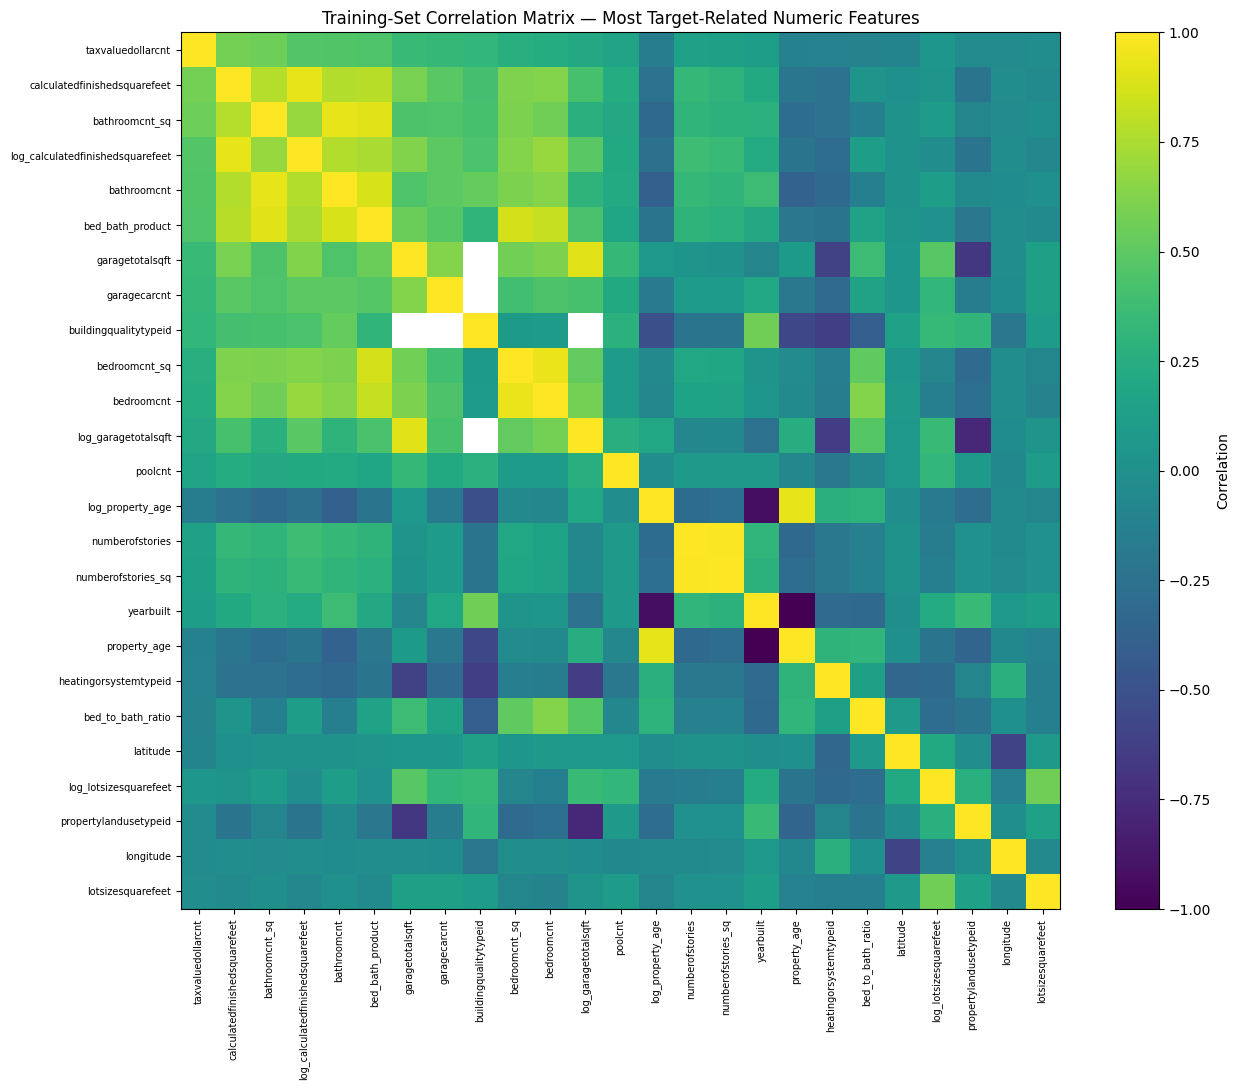

,Correlation with target
calculatedfinishedsquarefeet,0.584548
bathroomcnt_sq,0.557421
log_calculatedfinishedsquarefeet,0.468024
bathroomcnt,0.460056
bed_bath_product,0.451212
garagetotalsqft,0.348977
garagecarcnt,0.333348
buildingqualitytypeid,0.324345
bedroomcnt_sq,0.250830
bedroomcnt,0.234859


In [11]:
# Training-only correlation overview for numeric predictors
numeric_for_corr = X_train.select_dtypes(include=np.number).copy()
corr_frame = pd.concat([numeric_for_corr, y_train.rename(TARGET)], axis=1)

# Keep the chart readable by selecting the 25 numeric features most correlated with the target.
target_corr = corr_frame.corr(numeric_only=True)[TARGET].abs().sort_values(ascending=False)
heatmap_cols = target_corr.head(min(25, len(target_corr))).index.tolist()
corr_matrix = corr_frame[heatmap_cols].corr()

plt.figure(figsize=(13, 11))
plt.imshow(corr_matrix, aspect="auto", vmin=-1, vmax=1, cmap="viridis")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index, fontsize=7)
plt.title("Training-Set Correlation Matrix — Most Target-Related Numeric Features")
plt.tight_layout()
plt.show()

display(
    corr_frame.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
    .head(20)
    .to_frame("Correlation with target")
)


### Feature Relationships

Finished square footage had the strongest positive correlation with assessed value at about **0.58**. Bathroom count squared was also strongly related to value at about **0.56**, followed by log finished square footage, bathroom count, and the bedroom-bathroom interaction.

Property age had a negative relationship with assessed value, meaning older properties tended to have lower assessed values in this dataset.

These correlations are useful for understanding the data, but they do not mean that one feature directly causes property value to change.


## 7. Preprocessing Pipeline

The final dataset contains **24 numeric predictors** and **4 categorical predictors**.

For numeric variables, I use median imputation, missing-value indicators, and standardization. Categorical variables are imputed and one-hot encoded.

All preprocessing is included inside the sklearn pipeline so it is fitted separately within each cross-validation fold.


In [12]:
# Show which variables will be treated as numeric vs categorical.
preprocessor_preview, numeric_cols, categorical_cols = make_preprocessor(X_train)

print("Numeric predictors:", len(numeric_cols))
print(numeric_cols)
print("\nCategorical predictors:", len(categorical_cols))
print(categorical_cols)


Numeric predictors: 24
['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'garagecarcnt', 'garagetotalsqft', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'roomcnt', 'unitcnt', 'yearbuilt', 'numberofstories', 'property_age', 'log_property_age', 'bed_to_bath_ratio', 'bed_bath_product', 'bedroomcnt_sq', 'bathroomcnt_sq', 'numberofstories_sq', 'log_calculatedfinishedsquarefeet', 'log_lotsizesquarefeet', 'log_garagetotalsqft']

Categorical predictors: 4
['fips', 'propertylandusetypeid', 'airconditioningtypeid', 'heatingorsystemtypeid']


## 8. Baseline Model Comparison

I compared eight regression models using **5-fold cross-validation**:

- Linear Regression
- Ridge
- Lasso
- Decision Tree
- Bagging
- Random Forest
- AdaBoost
- Gradient Boosting

The main comparison metric is average cross-validation RMSE.


Evaluating Linear Regression...
Evaluating Ridge...
Evaluating Lasso...
Evaluating Decision Tree...
Evaluating Bagging...
Evaluating Random Forest...
Evaluating AdaBoost...
Evaluating Gradient Boosting...


,Model,Mean CV RMSE,CV RMSE Std,Runtime (sec)
0,Random Forest,431963.796230,60639.541323,638.658736
1,Bagging,432794.525575,58758.281176,218.599152
2,Gradient Boosting,435316.593950,52796.826564,94.476461
3,Ridge,481789.011612,45626.127267,1.111254
4,Lasso,481820.441488,45592.444652,641.484661
5,Linear Regression,481824.968650,45584.040886,4.125771
6,Decision Tree,579944.639243,57489.052721,7.207683
7,AdaBoost,907320.399798,347812.068208,26.159825


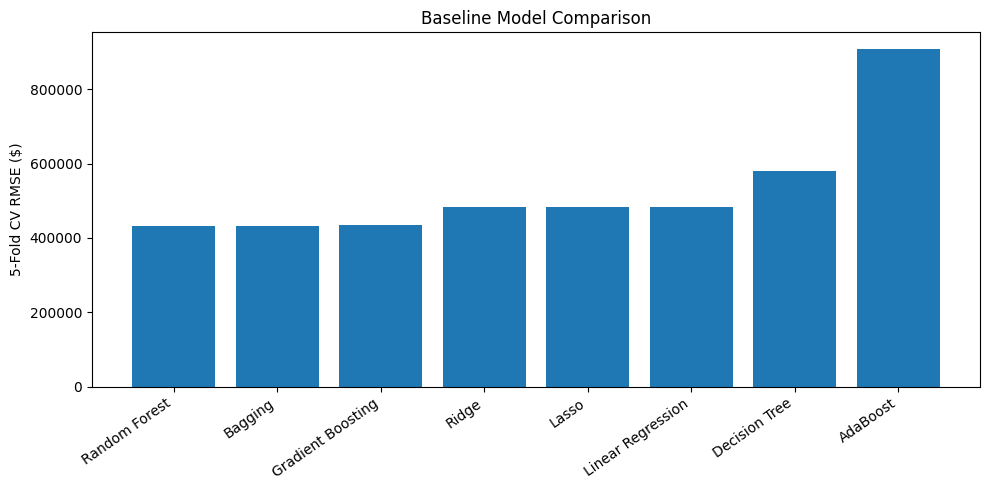

In [13]:
# 5-fold cross-validation for broad model comparison.
baseline_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0, max_iter=20000),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Bagging": BaggingRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=1),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "AdaBoost": AdaBoostRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

baseline_rows = []
for name, model in baseline_models.items():
    print(f"Evaluating {name}...")
    baseline_rows.append(evaluate_cv(name, model, X_train, y_train, baseline_cv))

baseline_results = (
    pd.DataFrame(baseline_rows)
    .sort_values("Mean CV RMSE")
    .reset_index(drop=True)
)

display(baseline_results)

plt.figure(figsize=(10, 5))
plt.bar(baseline_results["Model"], baseline_results["Mean CV RMSE"])
plt.ylabel("5-Fold CV RMSE ($)")
plt.title("Baseline Model Comparison")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### Baseline Results

Random Forest had the lowest baseline CV RMSE at about **$431,964**. Bagging was very close at **$432,795**, followed by Gradient Boosting at **$435,317**.

Gradient Boosting was much faster than Random Forest in this run, taking about **94 seconds** compared with about **639 seconds** for Random Forest. Ridge was the strongest linear model with an RMSE of about **$481,789**.

Based on these results, I continued with Gradient Boosting and Random Forest as the main tree-based models and kept Ridge as the linear benchmark.


## 9. Model Tuning

I used **3-fold cross-validation** for the tuning stage to reduce runtime while still comparing the models consistently.

I first tested individual parameters for Gradient Boosting, Random Forest, and Ridge. I then used broader hyperparameter searches to find better combinations of settings.


In [14]:
# Common CV used for every tuning comparison.
tuning_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


### 9.1 Gradient Boosting Parameter Sweeps


,Parameter,Value,Mean CV RMSE,CV RMSE Std
0,learning_rate,0.01,531940.251912,34446.883160
1,learning_rate,0.03,473261.943168,24735.839707
2,learning_rate,0.05,454340.875390,22506.265023
3,learning_rate,0.10,441901.461364,26130.086303
4,learning_rate,0.20,439056.436412,33645.446798
5,learning_rate,0.30,440525.878813,35803.630949


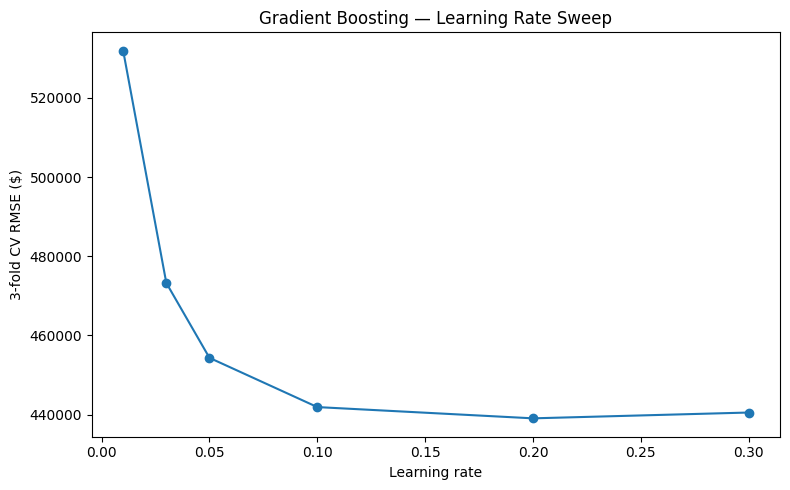

In [15]:
# Gradient Boosting: learning rate sweep
gb_base = GradientBoostingRegressor(random_state=RANDOM_STATE)

gb_lr_sweep = sweep_parameter(
    gb_base,
    "learning_rate",
    [0.01, 0.03, 0.05, 0.10, 0.20, 0.30],
    X_train,
    y_train,
    tuning_cv,
)
display(gb_lr_sweep)

plt.figure(figsize=(8, 5))
plt.plot(gb_lr_sweep["Value"], gb_lr_sweep["Mean CV RMSE"], marker="o")
plt.xlabel("Learning rate")
plt.ylabel("3-fold CV RMSE ($)")
plt.title("Gradient Boosting — Learning Rate Sweep")
plt.tight_layout()
plt.show()


,Parameter,Value,Mean CV RMSE,CV RMSE Std
0,n_estimators,50,454029.122736,25675.670724
1,n_estimators,100,441901.461364,26130.086303
2,n_estimators,150,437171.137105,29456.820724
3,n_estimators,200,436163.086706,31753.965313
4,n_estimators,250,434996.103925,34367.533221
5,n_estimators,300,435007.744819,35171.701527


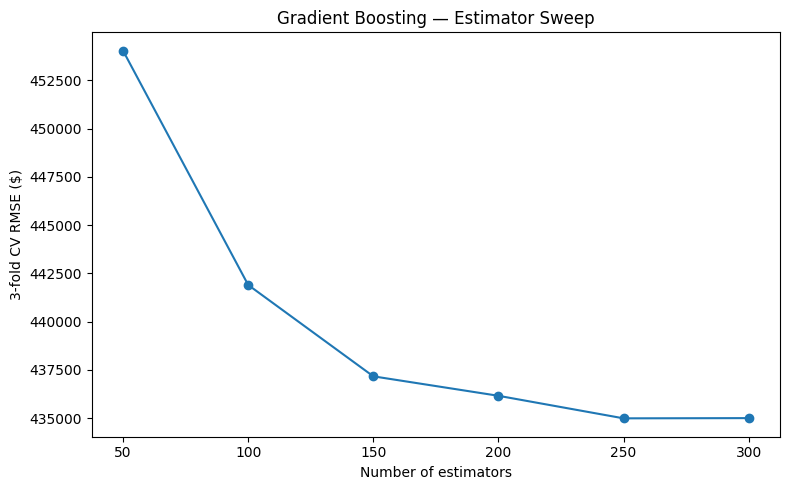

In [16]:
# Gradient Boosting: number of estimators sweep
gb_estimators_sweep = sweep_parameter(
    gb_base,
    "n_estimators",
    [50, 100, 150, 200, 250, 300],
    X_train,
    y_train,
    tuning_cv,
)
display(gb_estimators_sweep)

plt.figure(figsize=(8, 5))
plt.plot(gb_estimators_sweep["Value"], gb_estimators_sweep["Mean CV RMSE"], marker="o")
plt.xlabel("Number of estimators")
plt.ylabel("3-fold CV RMSE ($)")
plt.title("Gradient Boosting — Estimator Sweep")
plt.tight_layout()
plt.show()


,Parameter,Value,Mean CV RMSE,CV RMSE Std
0,max_depth,2,457437.538727,24317.839355
1,max_depth,3,441901.461364,26130.086303
2,max_depth,4,435364.265464,30870.259549
3,max_depth,5,427478.731735,24586.927418
4,max_depth,6,429342.358525,25190.674982
5,max_depth,7,437953.397908,30752.782451


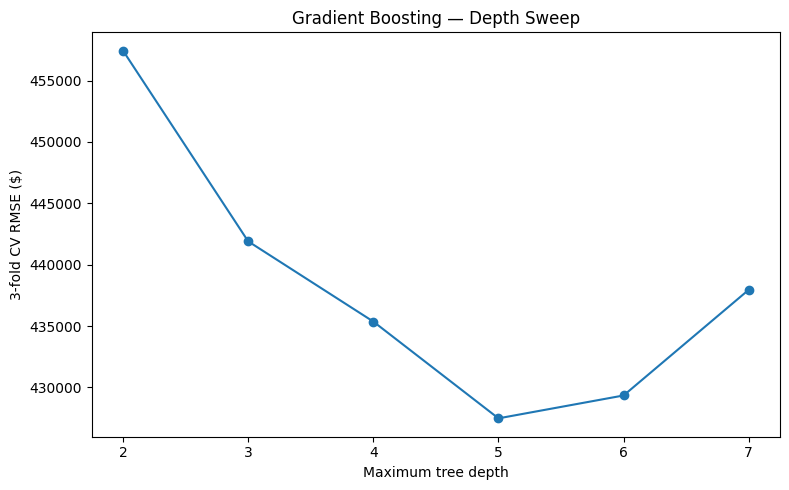

In [17]:
# Gradient Boosting: tree depth sweep
gb_depth_sweep = sweep_parameter(
    gb_base,
    "max_depth",
    [2, 3, 4, 5, 6, 7],
    X_train,
    y_train,
    tuning_cv,
)
display(gb_depth_sweep)

plt.figure(figsize=(8, 5))
plt.plot(gb_depth_sweep["Value"], gb_depth_sweep["Mean CV RMSE"], marker="o")
plt.xlabel("Maximum tree depth")
plt.ylabel("3-fold CV RMSE ($)")
plt.title("Gradient Boosting — Depth Sweep")
plt.tight_layout()
plt.show()


### 9.2 Random Forest Parameter Sweeps


,Parameter,Value,Mean CV RMSE,CV RMSE Std
0,max_depth,8.0,462087.131658,29098.428268
1,max_depth,12.0,443773.034893,32229.470232
2,max_depth,16.0,439386.819576,29595.803797
3,max_depth,24.0,441328.555516,31755.452690
4,max_depth,NaN,442412.390444,29565.604567


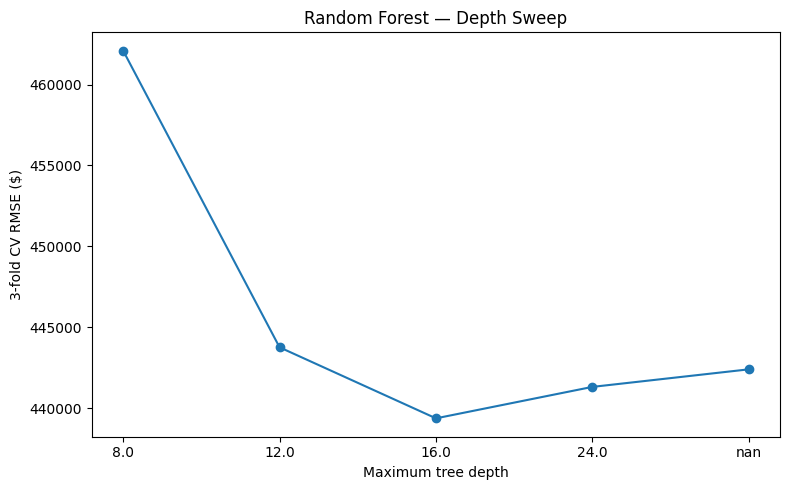

In [18]:
rf_base = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

rf_depth_sweep = sweep_parameter(
    rf_base,
    "max_depth",
    [8, 12, 16, 24, None],
    X_train,
    y_train,
    tuning_cv,
)
display(rf_depth_sweep)

# None cannot be plotted directly as a numeric x-value, so use labels.
plt.figure(figsize=(8, 5))
plt.plot(range(len(rf_depth_sweep)), rf_depth_sweep["Mean CV RMSE"], marker="o")
plt.xticks(range(len(rf_depth_sweep)), [str(v) for v in rf_depth_sweep["Value"]])
plt.xlabel("Maximum tree depth")
plt.ylabel("3-fold CV RMSE ($)")
plt.title("Random Forest — Depth Sweep")
plt.tight_layout()
plt.show()


,Parameter,Value,Mean CV RMSE,CV RMSE Std
0,min_samples_leaf,1,442412.390444,29565.604567
1,min_samples_leaf,2,439137.415694,32265.006166
2,min_samples_leaf,4,437992.373433,33424.199982
3,min_samples_leaf,8,442673.069374,34000.733983
4,min_samples_leaf,12,446950.271530,32476.812932


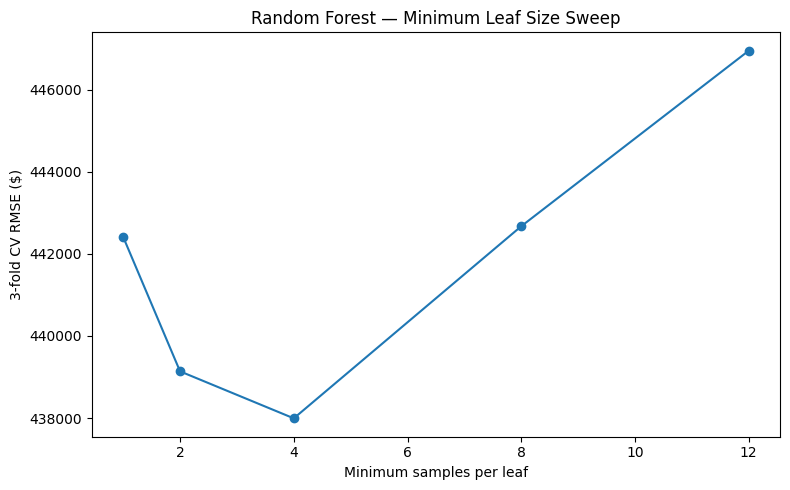

In [19]:
rf_leaf_sweep = sweep_parameter(
    rf_base,
    "min_samples_leaf",
    [1, 2, 4, 8, 12],
    X_train,
    y_train,
    tuning_cv,
)
display(rf_leaf_sweep)

plt.figure(figsize=(8, 5))
plt.plot(rf_leaf_sweep["Value"], rf_leaf_sweep["Mean CV RMSE"], marker="o")
plt.xlabel("Minimum samples per leaf")
plt.ylabel("3-fold CV RMSE ($)")
plt.title("Random Forest — Minimum Leaf Size Sweep")
plt.tight_layout()
plt.show()


### 9.3 Ridge Parameter Sweep


,Parameter,Value,Mean CV RMSE,CV RMSE Std
0,alpha,0.001000,479985.448644,12267.520218
1,alpha,0.004329,479985.131755,12267.029314
2,alpha,0.018738,479983.767595,12264.913086
3,alpha,0.081113,479978.001884,12255.914493
4,alpha,0.351119,479955.463764,12219.806512
5,alpha,1.519911,479891.380742,12104.500744
6,alpha,6.579332,479847.371707,11931.866371
7,alpha,28.480359,480148.847061,12037.768151
8,alpha,123.284674,482019.714700,12770.859159
9,alpha,533.669923,486466.548840,15219.111569


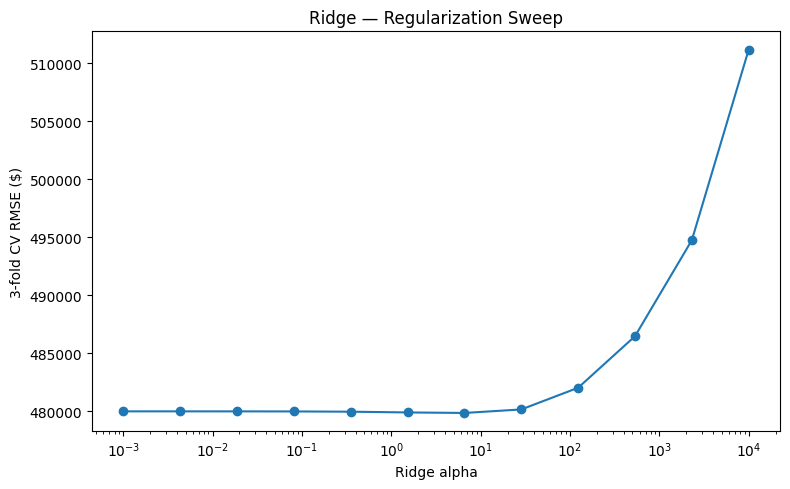

In [20]:
ridge_base = Ridge()
ridge_alphas = np.logspace(-3, 4, 12)

ridge_sweep = sweep_parameter(
    ridge_base,
    "alpha",
    ridge_alphas,
    X_train,
    y_train,
    tuning_cv,
)
display(ridge_sweep)

plt.figure(figsize=(8, 5))
plt.semilogx(ridge_sweep["Value"].astype(float), ridge_sweep["Mean CV RMSE"], marker="o")
plt.xlabel("Ridge alpha")
plt.ylabel("3-fold CV RMSE ($)")
plt.title("Ridge — Regularization Sweep")
plt.tight_layout()
plt.show()


### Parameter Sweep Results

For Gradient Boosting, increasing the learning rate improved RMSE up to about **0.20**, while moving to 0.30 gave slightly worse results. Increasing the number of estimators helped up to around **250 trees**, after which the improvement was very small. A tree depth of **5** gave the best result in the depth sweep, while deeper trees started to perform worse.

For Random Forest, a maximum depth around **16** performed best in the depth test. A `min_samples_leaf` value of **4** gave the lowest RMSE in that sweep.

For Ridge, performance was best around an alpha of **6.6**. Very large alpha values increased the error, showing that too much regularization hurt the model.


## 10. Hyperparameter Search

After the single-parameter tests, I ran broader searches using the same 3-fold cross-validation setup:

- **Gradient Boosting:** RandomizedSearchCV
- **Random Forest:** RandomizedSearchCV
- **Ridge:** GridSearchCV

The test set was not used during this stage.


In [21]:
# Gradient Boosting RandomizedSearchCV
# Parameters are prefixed with model__ because the estimator is inside a Pipeline.
gb_pipeline = make_model_pipeline(
    X_train,
    GradientBoostingRegressor(random_state=RANDOM_STATE),
)

gb_param_distributions = {
    "model__loss": ["squared_error", "huber", "absolute_error"],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20],
    "model__n_estimators": [100, 150, 200, 250, 300],
    "model__subsample": [0.70, 0.85, 1.0],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": [None, 0.5, 0.8, 1.0],
    "model__max_leaf_nodes": [None, 10, 20, 30],
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=GB_SEARCH_ITER,
    scoring="neg_root_mean_squared_error",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
)

start = time.time()
gb_search.fit(X_train, y_train)
print(f"Gradient Boosting search runtime: {time.time() - start:,.1f} seconds")
print("Best Gradient Boosting CV RMSE:", dollar(-gb_search.best_score_))
print("Best parameters:")
print(gb_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Gradient Boosting search runtime: 1,549.5 seconds
Best Gradient Boosting CV RMSE: $429,443
Best parameters:
{'model__subsample': 0.85, 'model__n_estimators': 250, 'model__min_samples_split': 20, 'model__min_samples_leaf': 1, 'model__max_leaf_nodes': 10, 'model__max_features': 1.0, 'model__max_depth': 6, 'model__loss': 'squared_error', 'model__learning_rate': 0.08}


In [22]:
# Random Forest RandomizedSearchCV
rf_pipeline = make_model_pipeline(
    X_train,
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
)

rf_param_distributions = {
    "model__n_estimators": [100, 150, 250, 350],
    "model__max_depth": [None, 10, 16, 24],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": [1.0, 0.8, 0.6, "sqrt"],
    "model__bootstrap": [True],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=RF_SEARCH_ITER,
    scoring="neg_root_mean_squared_error",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
)

start = time.time()
rf_search.fit(X_train, y_train)
print(f"Random Forest search runtime: {time.time() - start:,.1f} seconds")
print("Best Random Forest CV RMSE:", dollar(-rf_search.best_score_))
print("Best parameters:")
print(rf_search.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Random Forest search runtime: 2,927.7 seconds
Best Random Forest CV RMSE: $439,609
Best parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 0.8, 'model__max_depth': None, 'model__bootstrap': True}


In [23]:
# Ridge GridSearchCV
ridge_pipeline = make_model_pipeline(X_train, Ridge())

ridge_grid = {
    "model__alpha": np.logspace(-3, 5, 20),
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_grid,
    scoring="neg_root_mean_squared_error",
    cv=tuning_cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

start = time.time()
ridge_search.fit(X_train, y_train)
print(f"Ridge grid-search runtime: {time.time() - start:,.1f} seconds")
print("Best Ridge CV RMSE:", dollar(-ridge_search.best_score_))
print("Best parameters:")
print(ridge_search.best_params_)


Ridge grid-search runtime: 14.5 seconds
Best Ridge CV RMSE: $479,846
Best parameters:
{'model__alpha': np.float64(6.158482110660261)}


In [24]:
# Compare tuned candidate families using the same CV framework.
tuned_candidates = {
    "Gradient Boosting": gb_search,
    "Random Forest": rf_search,
    "Ridge": ridge_search,
}

tuned_comparison = pd.DataFrame([
    {
        "Model": name,
        "Best 3-fold CV RMSE": -search.best_score_,
        "Best Parameters": search.best_params_,
    }
    for name, search in tuned_candidates.items()
]).sort_values("Best 3-fold CV RMSE").reset_index(drop=True)

display(tuned_comparison)

best_model_name = tuned_comparison.loc[0, "Model"]
best_search = tuned_candidates[best_model_name]
final_model = best_search.best_estimator_  # already refit on all training rows
best_development_cv_rmse = -best_search.best_score_

print("Selected final model family:", best_model_name)
print("Selected development CV RMSE:", dollar(best_development_cv_rmse))


,Model,Best 3-fold CV RMSE,Best Parameters
0,Gradient Boosting,429442.789133,"{'model__subsample': 0.85, 'model__n_estimator..."
1,Random Forest,439609.209698,"{'model__n_estimators': 150, 'model__min_sampl..."
2,Ridge,479845.517532,{'model__alpha': 6.158482110660261}


Selected final model family: Gradient Boosting
Selected development CV RMSE: $429,443


### Tuned Model Selection

Gradient Boosting had the best tuned CV RMSE at about **$429,443**. Random Forest followed at about **$439,609**, while Ridge had an RMSE of about **$479,846**.

Since Gradient Boosting had the lowest tuning error, I selected it as the final model before evaluating the test set.


## 11. Validation Curve

I used a validation curve to see how Gradient Boosting performance changed as tree depth increased. This helps compare model fit on the training data with performance on validation data.


,max_depth,Train RMSE,Validation RMSE
0,2,380780.401170,463124.099092
1,3,342501.395333,447618.891026
2,4,318377.988387,435523.960643
3,5,307822.938281,430171.528847
4,6,299214.780744,429442.789133
5,7,295624.714528,425942.818001


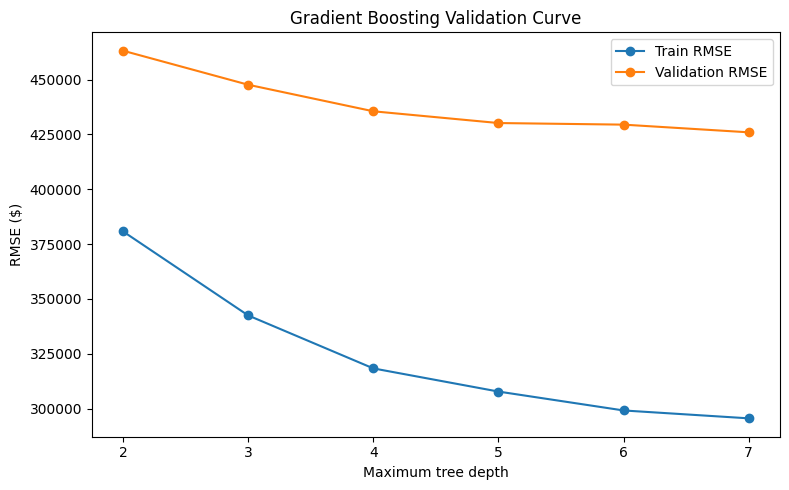

In [25]:
# Leakage-safe validation curve through the full pipeline.
# The curve is shown for Gradient Boosting because tree depth has a clear bias/variance interpretation.
gb_for_curve = clone(gb_search.best_estimator_)
param_range = [2, 3, 4, 5, 6, 7]

train_scores, valid_scores = validation_curve(
    gb_for_curve,
    X_train,
    y_train,
    param_name="model__max_depth",
    param_range=param_range,
    scoring="neg_root_mean_squared_error",
    cv=tuning_cv,
    n_jobs=-1,
)

train_rmse_curve = -train_scores.mean(axis=1)
valid_rmse_curve = -valid_scores.mean(axis=1)

validation_results = pd.DataFrame({
    "max_depth": param_range,
    "Train RMSE": train_rmse_curve,
    "Validation RMSE": valid_rmse_curve,
})
display(validation_results)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_rmse_curve, marker="o", label="Train RMSE")
plt.plot(param_range, valid_rmse_curve, marker="o", label="Validation RMSE")
plt.xlabel("Maximum tree depth")
plt.ylabel("RMSE ($)")
plt.title("Gradient Boosting Validation Curve")
plt.legend()
plt.tight_layout()
plt.show()


### Validation Curve Results

As tree depth increased, training RMSE continued to decrease. Validation RMSE also improved, dropping from about **$463,124 at depth 2** to about **$425,943 at depth 7**.

The gap between training and validation error became larger at deeper trees, which shows that the model was fitting the training data more closely. The tuned final model used depth 6 together with other parameter settings, so the final choice was based on the full hyperparameter search rather than tree depth alone.


# 12. Final Results

After selecting Gradient Boosting using cross-validation, I evaluated it on the held-out test set.


In [26]:
# Final held-out evaluation — this is the first point where y_test is used for model performance.
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

final_metrics = pd.DataFrame({
    "Metric": [
        "Selected model",
        "Best development CV RMSE",
        "Train RMSE",
        "Held-out Test RMSE",
        "Held-out Test MAE",
        "Held-out Test R²",
    ],
    "Value": [
        best_model_name,
        best_development_cv_rmse,
        rmse(y_train, train_pred),
        rmse(y_test, test_pred),
        mean_absolute_error(y_test, test_pred),
        r2_score(y_test, test_pred),
    ],
})

display(final_metrics)

print("Final model:", best_model_name)
print("Development CV RMSE:", dollar(best_development_cv_rmse))
print("Train RMSE:", dollar(rmse(y_train, train_pred)))
print("Test RMSE:", dollar(rmse(y_test, test_pred)))
print("Test MAE:", dollar(mean_absolute_error(y_test, test_pred)))
print(f"Test R²: {r2_score(y_test, test_pred):.4f}")


,Metric,Value
0,Selected model,Gradient Boosting
1,Best development CV RMSE,429442.789133
2,Train RMSE,311264.531869
3,Held-out Test RMSE,438822.848195
4,Held-out Test MAE,195896.758247
5,Held-out Test R²,0.55722


Final model: Gradient Boosting
Development CV RMSE: $429,443
Train RMSE: $311,265
Test RMSE: $438,823
Test MAE: $195,897
Test R²: 0.5572


### Final Model Performance

The final Gradient Boosting model produced:

- **Training RMSE:** $311,265
- **Development CV RMSE:** $429,443
- **Test RMSE:** $438,823
- **Test MAE:** $195,897
- **Test R²:** 0.557

The test RMSE is fairly close to the cross-validation RMSE, which means the model performed on the test set about as expected from training. The training RMSE is noticeably lower, so there is some overfitting, but the cross-validation and test results are much closer to each other.

The R² of **0.557** means the model explains about **56% of the variation** in assessed property values. The MAE shows that the average absolute prediction error is about **$195,897**.


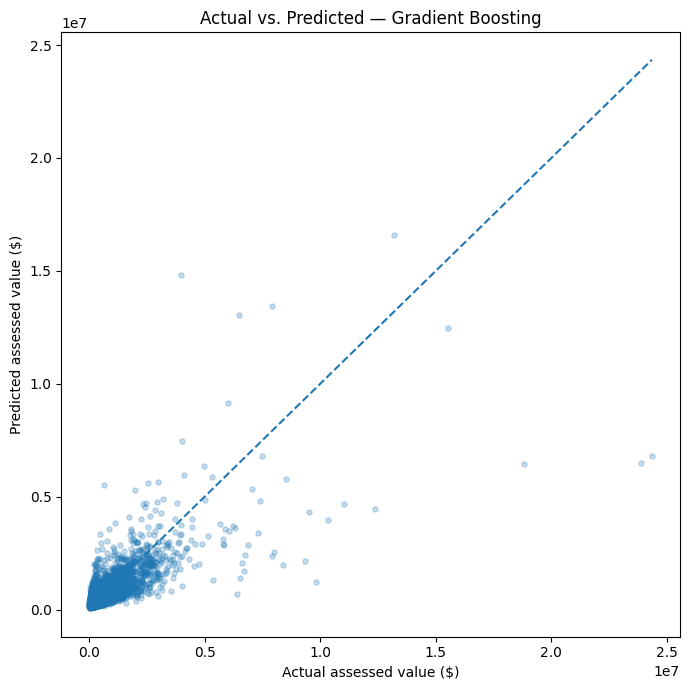

In [27]:
# Actual vs predicted
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_pred, alpha=0.25, s=14)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual assessed value ($)")
plt.ylabel("Predicted assessed value ($)")
plt.title(f"Actual vs. Predicted — {best_model_name}")
plt.tight_layout()
plt.show()


## 13. Error Analysis

I looked at residuals and prediction errors across different property-value ranges to understand where the model performs well and where it struggles.


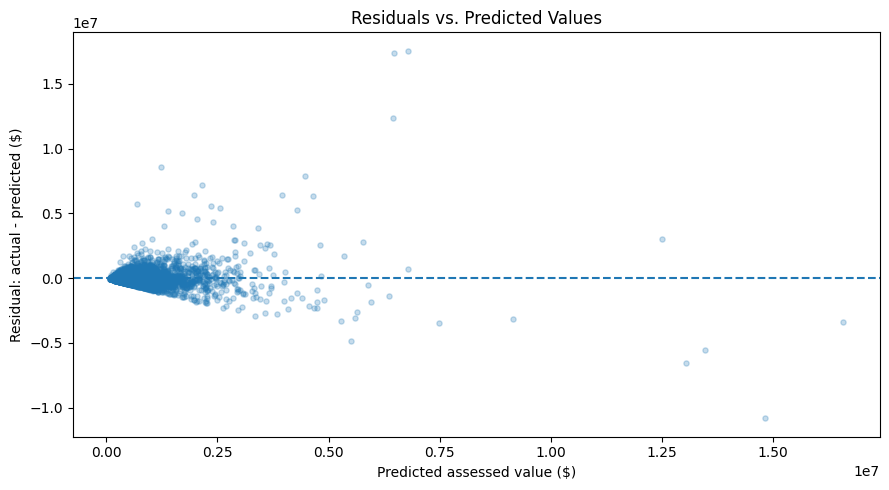

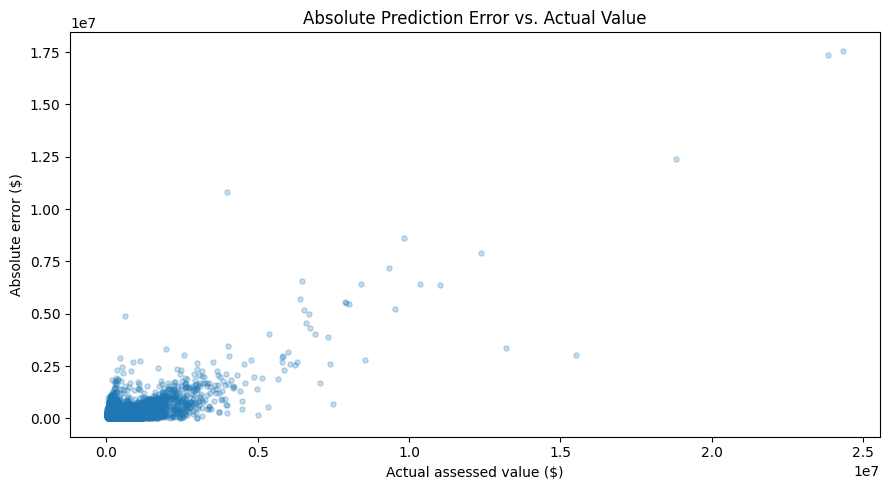

In [28]:
# Residual diagnostics
residuals = y_test.to_numpy() - test_pred
absolute_errors = np.abs(residuals)

plt.figure(figsize=(9, 5))
plt.scatter(test_pred, residuals, alpha=0.25, s=14)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted assessed value ($)")
plt.ylabel("Residual: actual - predicted ($)")
plt.title("Residuals vs. Predicted Values")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(y_test, absolute_errors, alpha=0.25, s=14)
plt.xlabel("Actual assessed value ($)")
plt.ylabel("Absolute error ($)")
plt.title("Absolute Prediction Error vs. Actual Value")
plt.tight_layout()
plt.show()


,value_decile,observations,mean_actual,MAE,RMSE
0,"(13615.999, 103448.5]",1548,6.789822e+04,235459.281246,2.617715e+05
1,"(103448.5, 176344.0]",1548,1.408529e+05,187520.546866,2.659838e+05
2,"(176344.0, 237861.5]",1547,2.076962e+05,106224.654591,1.802182e+05
3,"(237861.5, 299490.0]",1548,2.678357e+05,97796.929531,1.766935e+05
4,"(299490.0, 358989.5]",1547,3.293263e+05,100615.255608,1.824431e+05
5,"(358989.5, 425000.0]",1549,3.909859e+05,102099.733427,1.503052e+05
6,"(425000.0, 509712.5]",1546,4.642956e+05,129921.887574,1.927486e+05
7,"(509712.5, 644683.0]",1548,5.718200e+05,160380.242911,2.377206e+05
8,"(644683.0, 908024.0]",1547,7.572862e+05,216010.775989,2.784161e+05
9,"(908024.0, 24345695.0]",1548,1.712483e+06,622807.142749,1.222807e+06


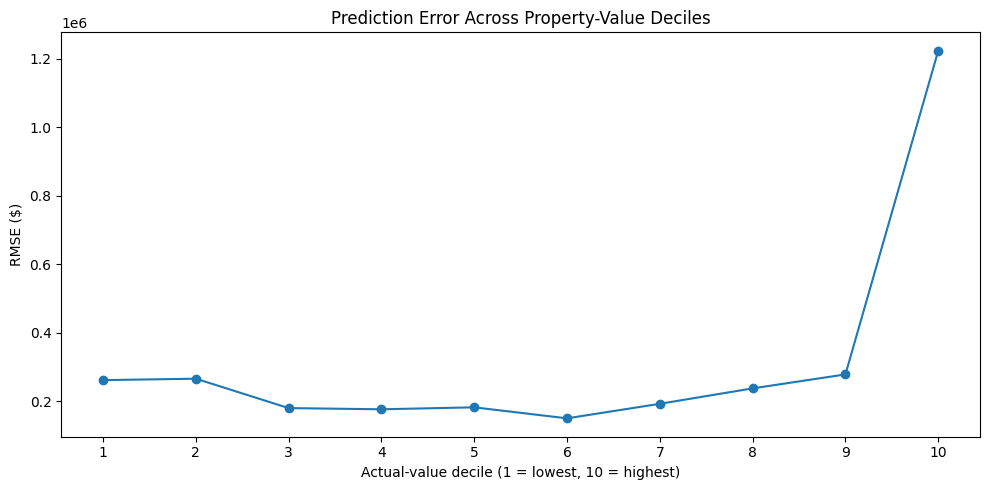

In [29]:
# Error by actual-value decile
error_df = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predicted": test_pred,
})
error_df["absolute_error"] = np.abs(error_df["actual"] - error_df["predicted"])
error_df["squared_error"] = (error_df["actual"] - error_df["predicted"]) ** 2
error_df["value_decile"] = pd.qcut(error_df["actual"], q=10, duplicates="drop")

decile_error = (
    error_df.groupby("value_decile", observed=True)
    .agg(
        observations=("actual", "size"),
        mean_actual=("actual", "mean"),
        MAE=("absolute_error", "mean"),
        MSE=("squared_error", "mean"),
    )
    .reset_index()
)
decile_error["RMSE"] = np.sqrt(decile_error["MSE"])
decile_error = decile_error.drop(columns="MSE")

display(decile_error)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(decile_error) + 1), decile_error["RMSE"], marker="o")
plt.xlabel("Actual-value decile (1 = lowest, 10 = highest)")
plt.ylabel("RMSE ($)")
plt.title("Prediction Error Across Property-Value Deciles")
plt.xticks(range(1, len(decile_error) + 1))
plt.tight_layout()
plt.show()


In [30]:
# Post-hoc extreme-value diagnostic.
# The threshold is learned from y_train and is NOT used to train or select the model.
training_p99 = y_train.quantile(0.99)
core_mask = y_test <= training_p99
extreme_mask = y_test > training_p99

range_diagnostics = []

if core_mask.sum() > 0:
    range_diagnostics.append({
        "Segment": f"Core range (<= training 99th pct: {dollar(training_p99)})",
        "Observations": int(core_mask.sum()),
        "RMSE": rmse(y_test[core_mask], test_pred[core_mask]),
        "MAE": mean_absolute_error(y_test[core_mask], test_pred[core_mask]),
    })

if extreme_mask.sum() > 0:
    range_diagnostics.append({
        "Segment": f"Extreme range (> training 99th pct: {dollar(training_p99)})",
        "Observations": int(extreme_mask.sum()),
        "RMSE": rmse(y_test[extreme_mask], test_pred[extreme_mask]),
        "MAE": mean_absolute_error(y_test[extreme_mask], test_pred[extreme_mask]),
    })

display(pd.DataFrame(range_diagnostics))


,Segment,Observations,RMSE,MAE
0,"Core range (<= training 99th pct: $2,783,852)",15331,2.718536e+05,1.756686e+05
1,"Extreme range (> training 99th pct: $2,783,852)",145,3.569136e+06,2.334641e+06


### Error Analysis Results

The model performs best for many properties in the middle of the value range. Errors increase at both ends, but the largest problem is with very expensive properties.

For the highest value decile, MAE rises to about **$622,807**, much higher than the middle deciles. Properties above the training-set 99th percentile of about **$2.78 million** had an RMSE of about **$3.57 million**, compared with about **$271,854** for the rest of the test set.

This shows that a small number of very high-value properties have a large effect on the overall RMSE. These properties may depend on features such as luxury condition, renovations, views, or neighborhood details that are not fully captured in the dataset.


## 14. Feature Importance

I used permutation importance to measure how much model performance changes when each feature is randomly shuffled. A larger change in error means the model depends more on that feature for its predictions.


,Feature,Importance Mean,Importance Std
9,latitude,279457.159276,4619.066997
10,longitude,275473.295750,6302.915925
25,log_calculatedfinishedsquarefeet,70325.768562,3748.814119
4,calculatedfinishedsquarefeet,67751.578058,3056.404710
3,buildingqualitytypeid,20861.884047,628.901884
13,propertylandusetypeid,14548.260682,2430.847305
26,log_lotsizesquarefeet,9060.835451,2689.154285
8,heatingorsystemtypeid,7671.745006,835.511490
16,yearbuilt,7049.628568,1077.300150
1,bathroomcnt,3762.723949,377.459954


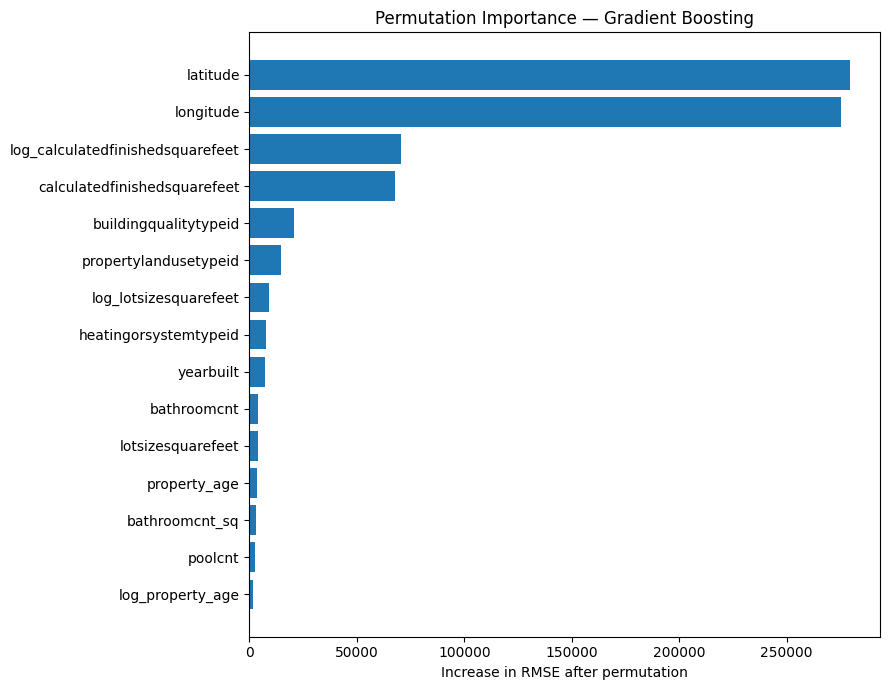

In [31]:
# Permutation importance on original input columns.
# For runtime, this can be reduced to 3 repeats if needed.
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm.importances_mean,
    "Importance Std": perm.importances_std,
}).sort_values("Importance Mean", ascending=False)

display(importance_df.head(20))

plot_imp = importance_df.head(15).sort_values("Importance Mean")
plt.figure(figsize=(9, 7))
plt.barh(plot_imp["Feature"], plot_imp["Importance Mean"])
plt.xlabel("Increase in RMSE after permutation")
plt.title(f"Permutation Importance — {best_model_name}")
plt.tight_layout()
plt.show()


### Feature Importance Results

Location was the strongest part of the model. **Latitude and longitude** had the largest permutation importance by a wide margin.

Property size was also important. Both finished square footage and its log-transformed version ranked near the top. Building quality, property land-use type, lot size, and year built also contributed to the predictions.

These importance values show which variables were most useful to the model. They should not be interpreted as proof that a feature directly causes property values to change.


## 15. Model Development Summary

The results are kept separate by stage:

- **Baseline comparison:** 5-fold cross-validation
- **Model tuning:** 3-fold cross-validation
- **Final evaluation:** held-out test set

This keeps the test set separate from the model-selection process.


In [34]:
# Summary of model development and final test performance

print("BASELINE 5-FOLD CV RESULTS")
display(
    baseline_results[
        ["Model", "Mean CV RMSE", "CV RMSE Std", "Runtime (sec)"]
    ]
)

print("\nTUNED 3-FOLD CV RESULTS")
display(
    tuned_comparison[
        ["Model", "Best 3-fold CV RMSE", "Best Parameters"]
    ]
)

print("\nFINAL HELD-OUT TEST RESULTS")

heldout_summary = pd.DataFrame({
    "Model": [best_model_name],
    "Test RMSE": [rmse(y_test, test_pred)],
    "Test MAE": [mean_absolute_error(y_test, test_pred)],
    "Test R²": [r2_score(y_test, test_pred)],
})

display(heldout_summary)

BASELINE 5-FOLD CV RESULTS


,Model,Mean CV RMSE,CV RMSE Std,Runtime (sec)
0,Random Forest,431963.796230,60639.541323,638.658736
1,Bagging,432794.525575,58758.281176,218.599152
2,Gradient Boosting,435316.593950,52796.826564,94.476461
3,Ridge,481789.011612,45626.127267,1.111254
4,Lasso,481820.441488,45592.444652,641.484661
5,Linear Regression,481824.968650,45584.040886,4.125771
6,Decision Tree,579944.639243,57489.052721,7.207683
7,AdaBoost,907320.399798,347812.068208,26.159825



TUNED 3-FOLD CV RESULTS


,Model,Best 3-fold CV RMSE,Best Parameters
0,Gradient Boosting,429442.789133,"{'model__subsample': 0.85, 'model__n_estimator..."
1,Random Forest,439609.209698,"{'model__n_estimators': 150, 'model__min_sampl..."
2,Ridge,479845.517532,{'model__alpha': 6.158482110660261}



FINAL HELD-OUT TEST RESULTS


,Model,Test RMSE,Test MAE,Test R²
0,Gradient Boosting,438822.848195,195896.758247,0.55722


## 16. Conclusion

Gradient Boosting was the best model after tuning, with a **3-fold CV RMSE of $429,443**. On the held-out test set, it achieved an **RMSE of $438,823**, an **MAE of $195,897**, and an **R² of 0.557**.

The model captured a meaningful amount of the variation in property values, especially using location and property size. Its main weakness was predicting very expensive properties, where errors increased sharply.

### Limitations

The dataset does not include every factor that can affect property value. Renovation quality, interior condition, neighborhood amenities, views, recent comparable sales, and other local market details could improve the model. Some predictors also contain substantial missing data.

The data is from 2016, so this model should be viewed as a portfolio analysis of the Zillow dataset rather than a current property valuation tool.

### Future Work

Possible next steps would be to test models such as XGBoost or LightGBM, add more detailed neighborhood information, and compare the current target with a log-transformed target to see whether it improves predictions for high-value properties.
